In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set clean plot style
sns.set_theme(style="whitegrid", palette="muted")

# Load data (Update path if needed)
base_path = '../csvs/'
train = pd.read_csv(base_path + 'train.csv')
test = pd.read_csv(base_path + 'test.csv')

print("✅ Data loaded successfully.")

✅ Data loaded successfully.


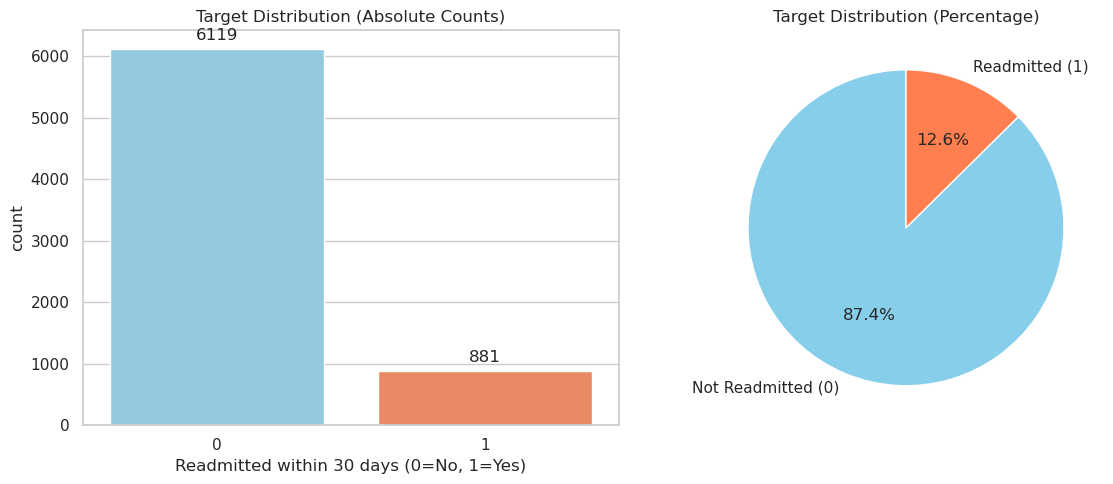

🎯 Baseline Readmission Rate: 0.1259


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Absolute Counts
sns.countplot(x='readmitted_30d', data=train, ax=axes[0], palette=['#87CEEB', '#FF7F50'])
axes[0].set_title('Target Distribution (Absolute Counts)')
axes[0].set_xlabel('Readmitted within 30 days (0=No, 1=Yes)')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Percentages
labels = ['Not Readmitted (0)', 'Readmitted (1)']
sizes = train['readmitted_30d'].value_counts()
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#87CEEB', '#FF7F50'])
axes[1].set_title('Target Distribution (Percentage)')

plt.tight_layout()
plt.show()

print(f"🎯 Baseline Readmission Rate: {train['readmitted_30d'].mean():.4f}")

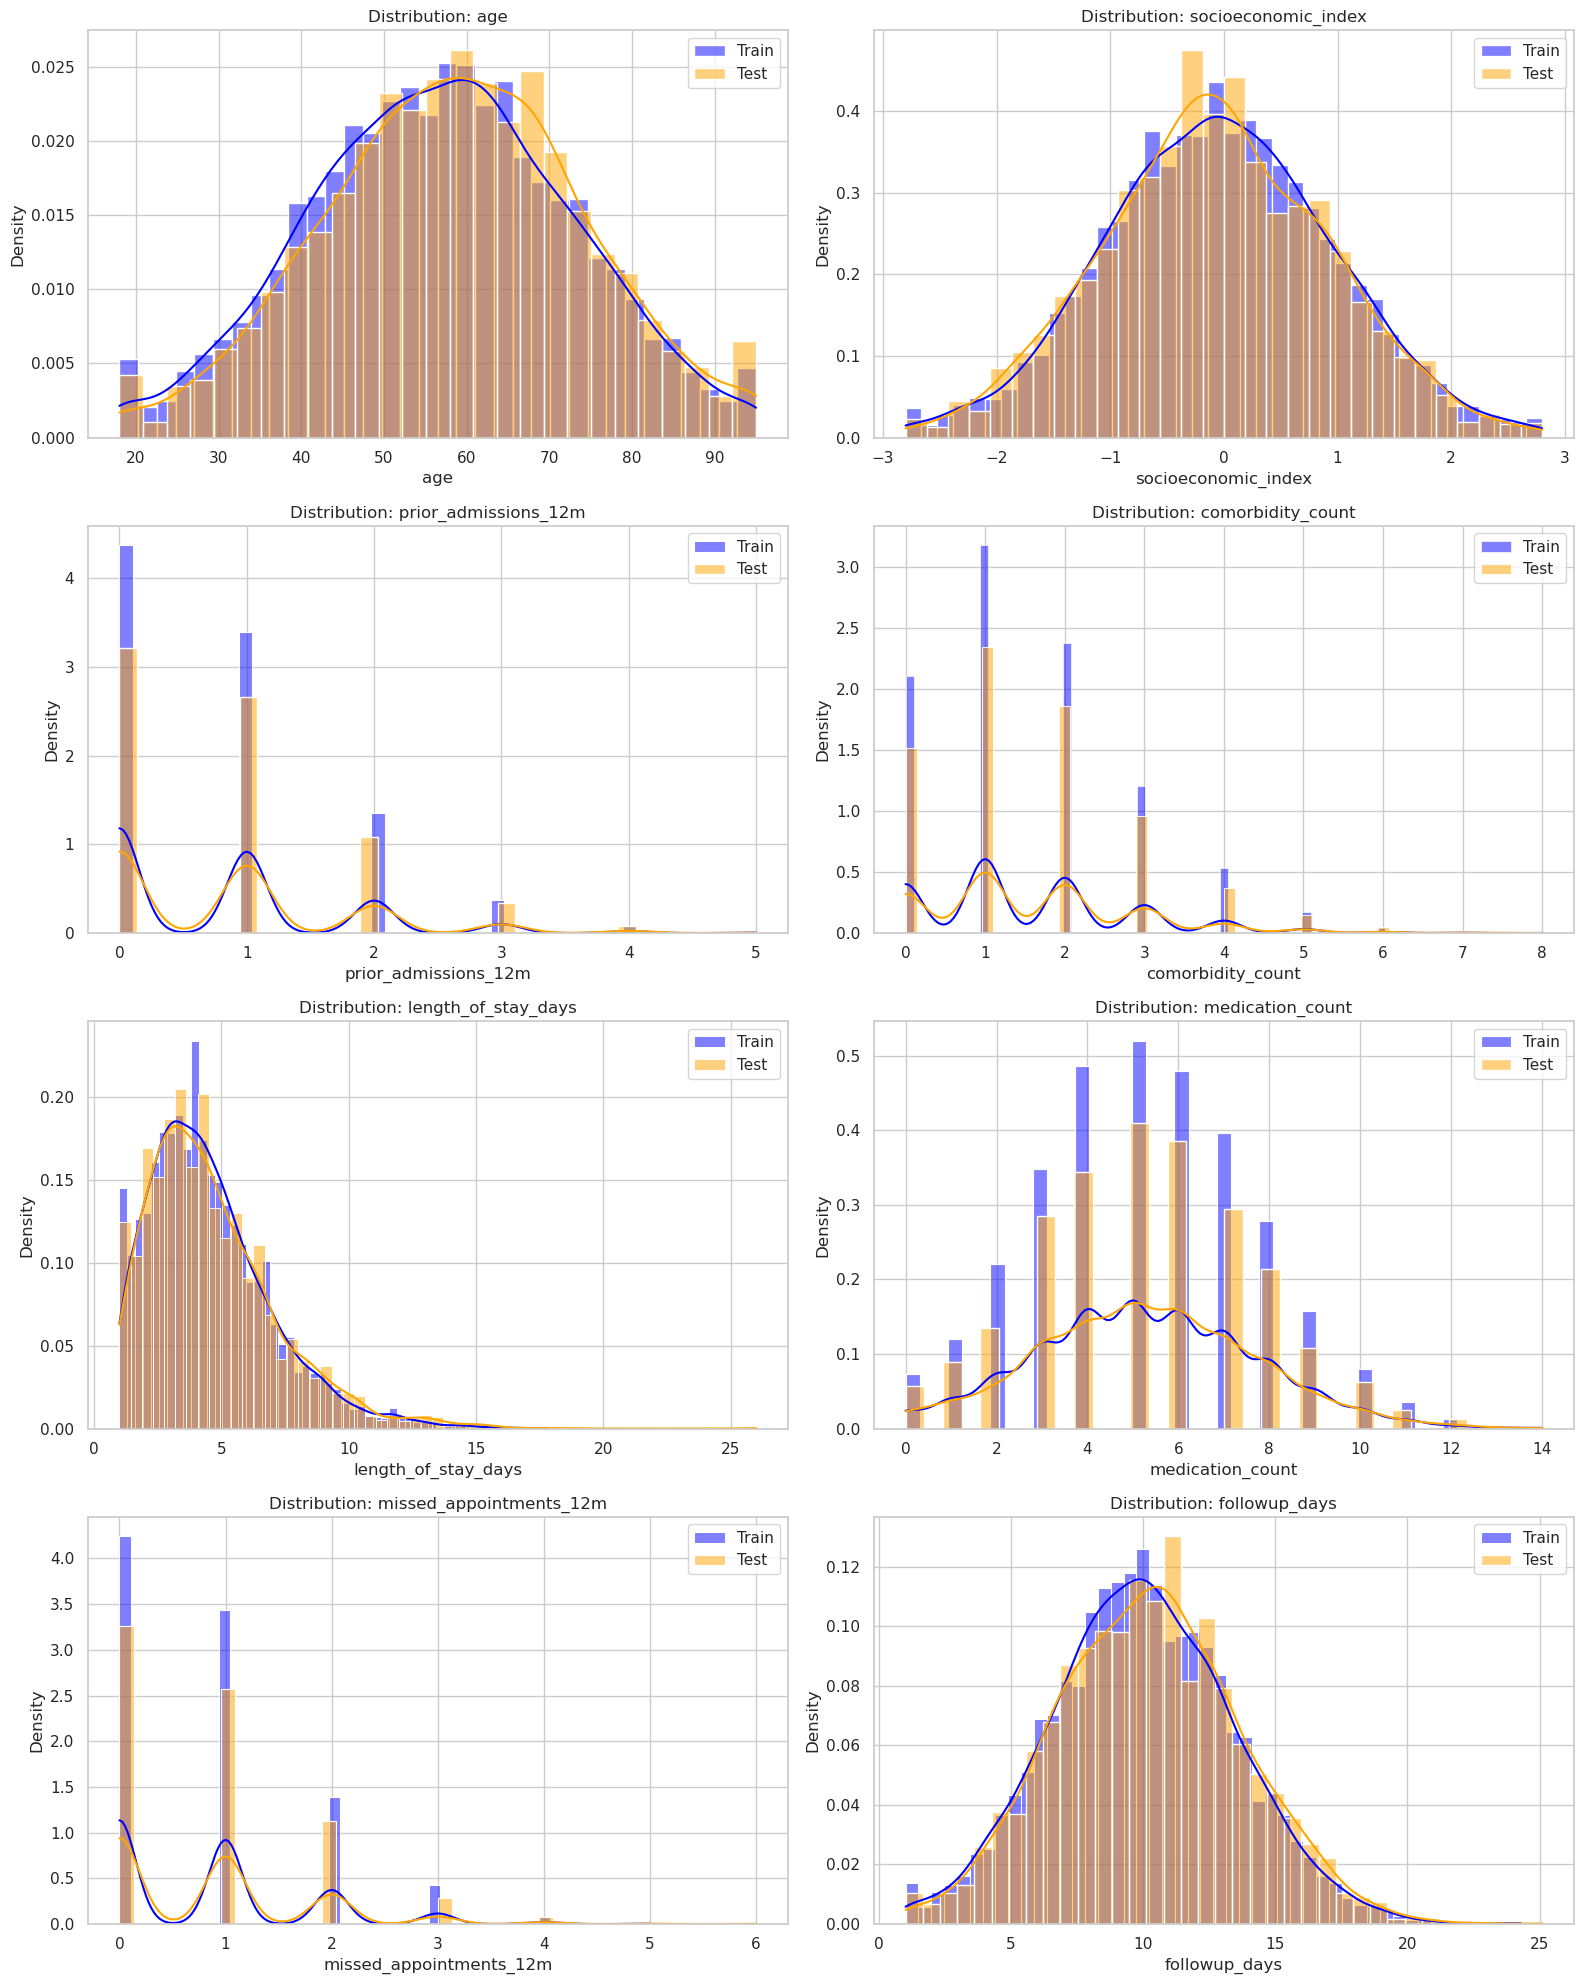

In [4]:
numeric_cols = ['age', 'socioeconomic_index', 'prior_admissions_12m', 'comorbidity_count', 
                'length_of_stay_days', 'medication_count', 'missed_appointments_12m', 'followup_days']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Plot density to compare shapes regardless of dataset size differences
    sns.histplot(train[col].dropna(), kde=True, ax=axes[i], color='blue', label='Train', stat='density')
    sns.histplot(test[col].dropna(), kde=True, ax=axes[i], color='orange', label='Test', stat='density')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].legend()

plt.tight_layout()
plt.show()

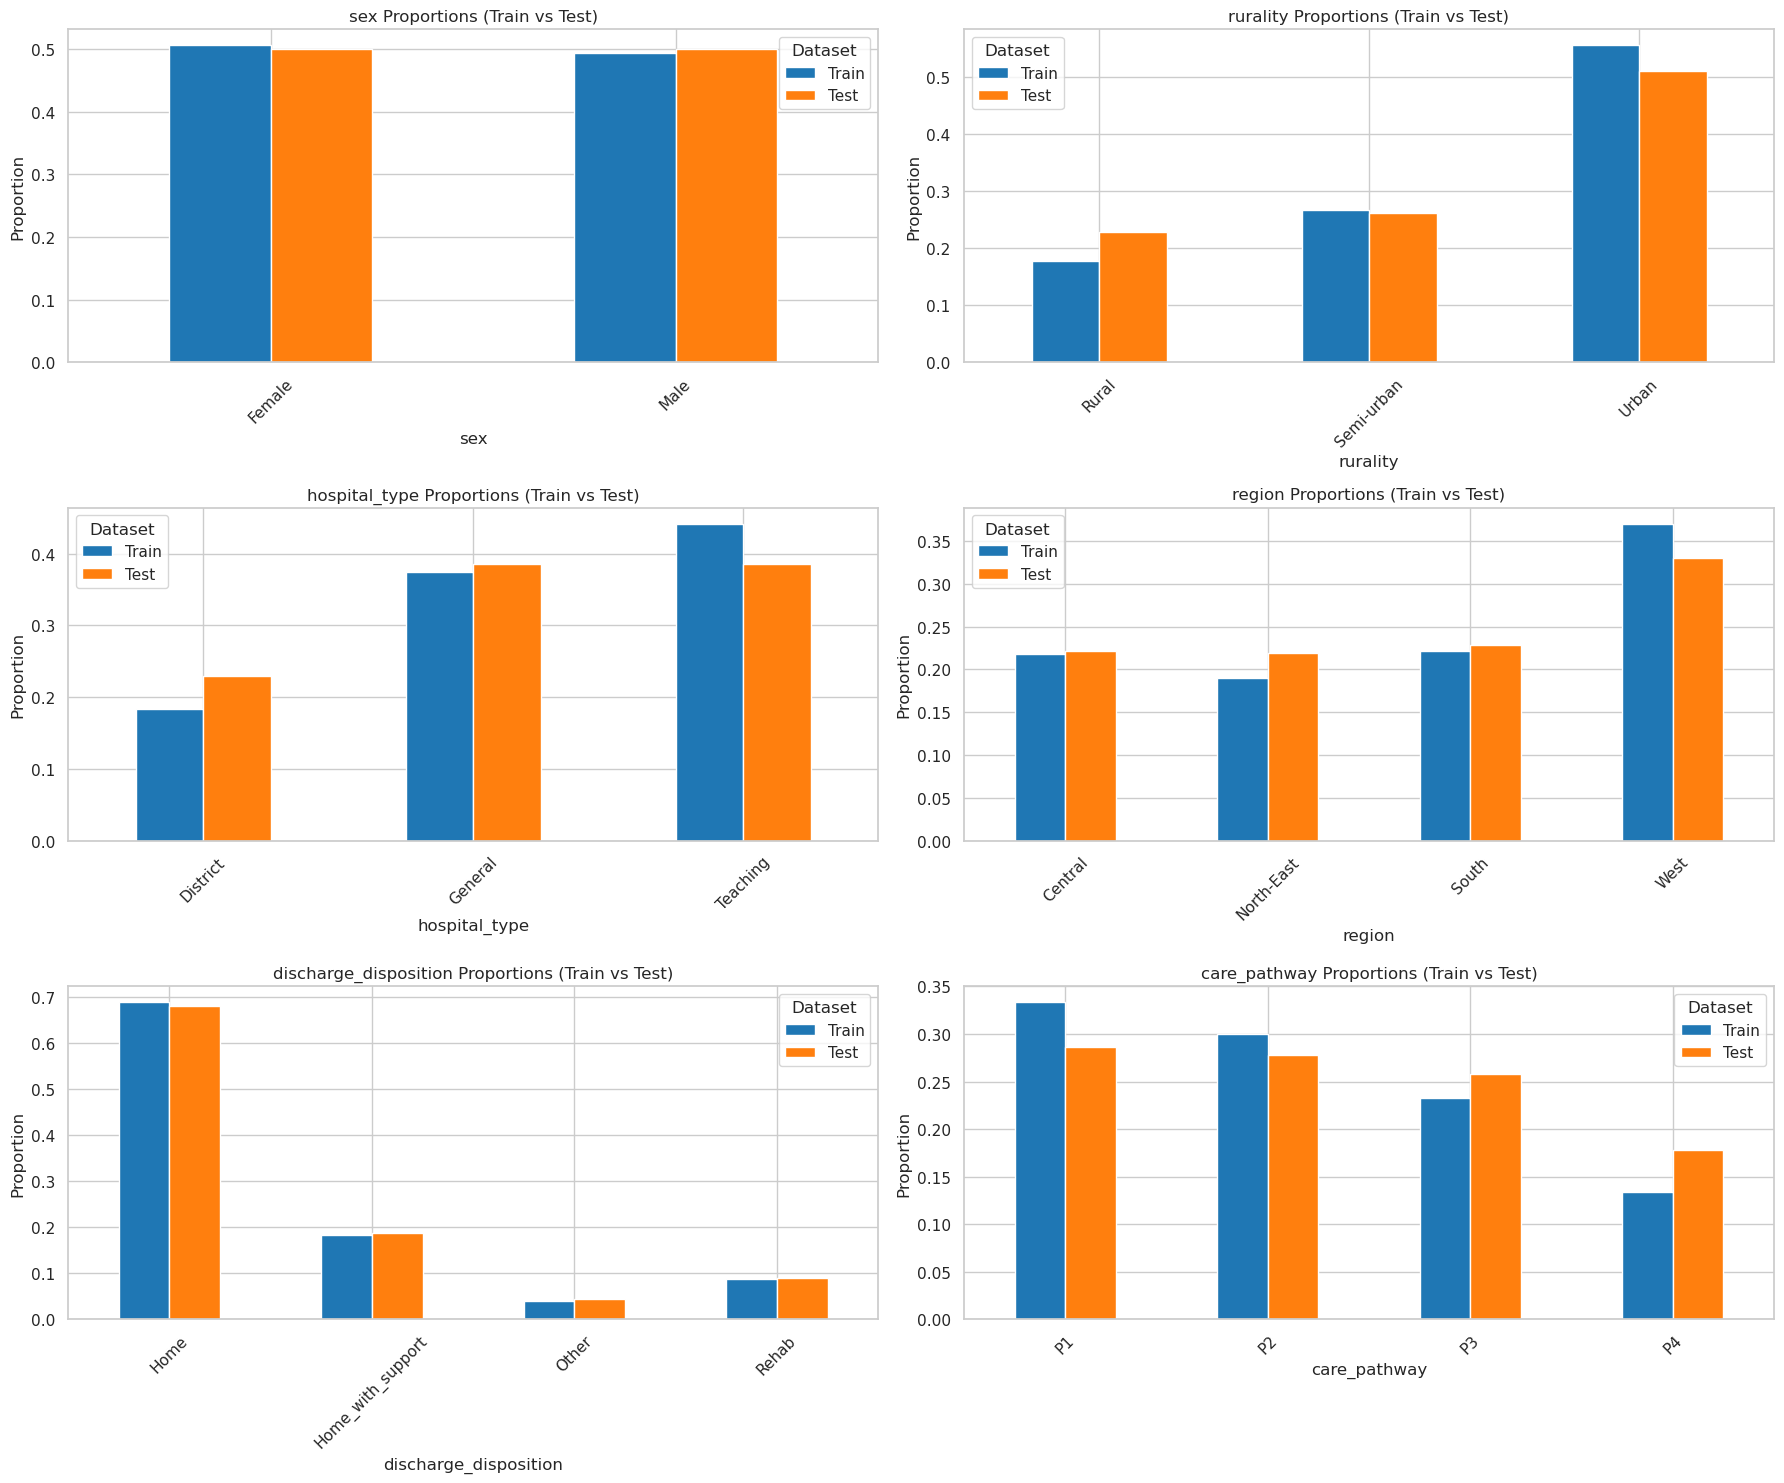

--- Categorical Cardinality (Unique Values) ---
sex: 2 in Train | 2 in Test
rurality: 3 in Train | 3 in Test
hospital_type: 3 in Train | 3 in Test
region: 4 in Train | 4 in Test
discharge_disposition: 4 in Train | 4 in Test
care_pathway: 4 in Train | 4 in Test


In [5]:
categorical_cols = ['sex', 'rurality', 'hospital_type', 'region', 'discharge_disposition', 'care_pathway']

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Calculate proportions for fair comparison
    train_counts = train[col].value_counts(normalize=True).sort_index()
    test_counts = test[col].value_counts(normalize=True).sort_index()
    
    plot_df = pd.DataFrame({'Train': train_counts, 'Test': test_counts}).fillna(0)
    
    plot_df.plot(kind='bar', ax=axes[i], color=['#1f77b4', '#ff7f0e'])
    axes[i].set_title(f'{col} Proportions (Train vs Test)')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Dataset')

plt.tight_layout()
plt.show()

print("--- Categorical Cardinality (Unique Values) ---")
for col in categorical_cols:
    print(f"{col}: {train[col].nunique()} in Train | {test[col].nunique()} in Test")

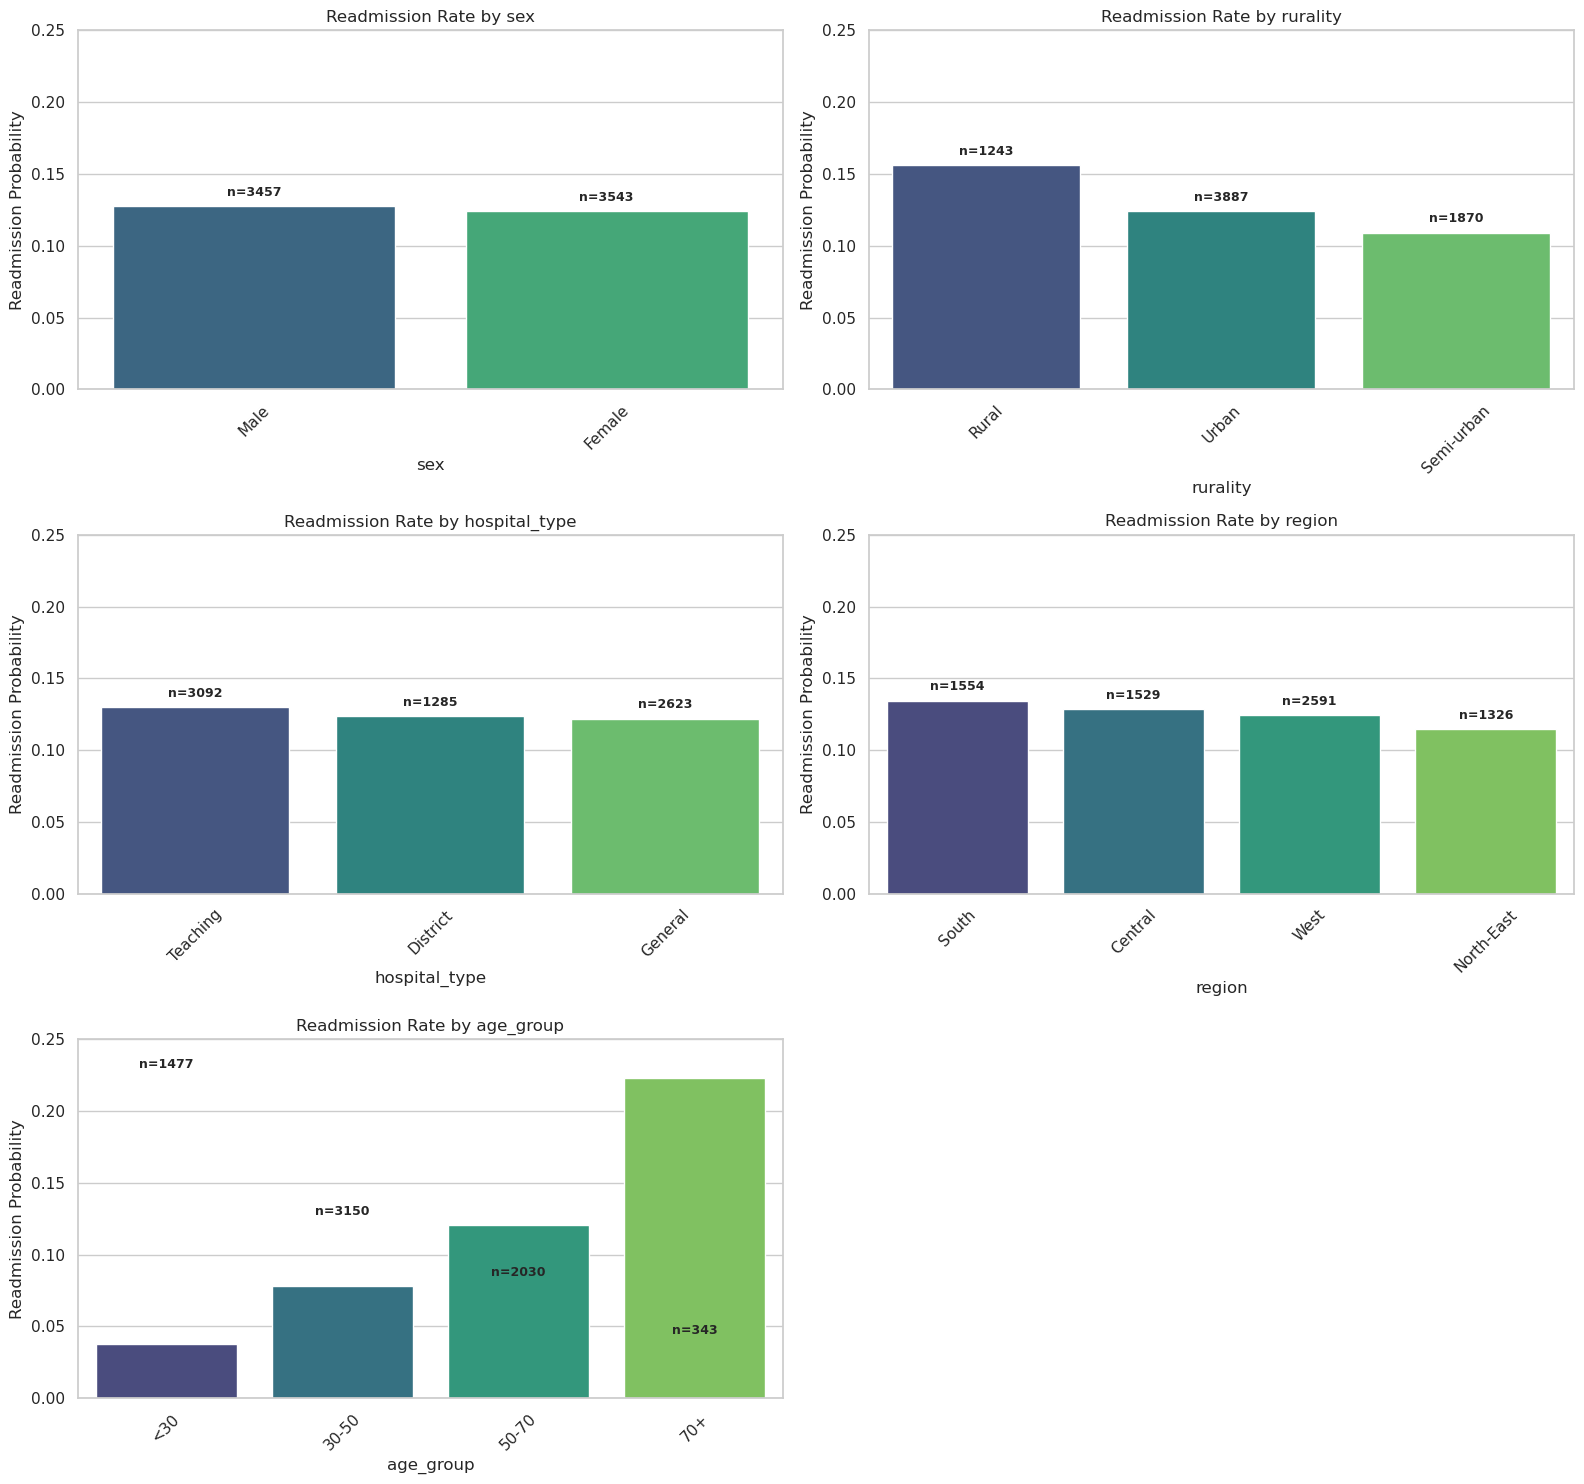

In [6]:
# Create Age Groups
train['age_group'] = pd.cut(train['age'], bins=[0, 30, 50, 70, 120], labels=['<30', '30-50', '50-70', '70+'])

subgroup_cols = ['sex', 'rurality', 'hospital_type', 'region', 'age_group']

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

for i, col in enumerate(subgroup_cols):
    subgroup_stats = train.groupby(col)['readmitted_30d'].agg(['mean', 'count']).reset_index()
    subgroup_stats = subgroup_stats.sort_values('mean', ascending=False)
    
    sns.barplot(x=col, y='mean', data=subgroup_stats, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Readmission Rate by {col}')
    axes[i].set_ylabel('Readmission Probability')
    axes[i].set_ylim(0, 0.25) # Fixed Y-axis for easy visual comparison
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add sample size (n) on top of bars
    for j, row in enumerate(subgroup_stats.itertuples()):
        axes[i].text(j, row.mean + 0.005, f'n={row.count}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Hide empty subplot
if len(subgroup_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [7]:
missing_cols = ['followup_days', 'hemoglobin_g_dl', 'creatinine_mg_dl', 'sodium_mmol_l', 'heart_rate_bpm', 'systolic_bp_mmhg']

missing_analysis = []

for col in missing_cols:
    is_missing = train[col].isnull()
    
    if is_missing.sum() > 0:
        rate_missing = is_missing.mean() * 100
        target_rate_missing = train.loc[is_missing, 'readmitted_30d'].mean()
        target_rate_present = train.loc[~is_missing, 'readmitted_30d'].mean()
        
        missing_analysis.append({
            'Feature': col,
            'Missing %': rate_missing,
            'Risk if Missing': target_rate_missing,
            'Risk if Present': target_rate_present,
            'Risk Difference': target_rate_missing - target_rate_present
        })

missing_df = pd.DataFrame(missing_analysis).sort_values('Risk Difference', ascending=False)

print("--- Does Missing Data Indicate Higher or Lower Risk? ---")
display(missing_df.style.format({
    'Missing %': '{:.2f}%', 
    'Risk if Missing': '{:.4f}', 
    'Risk if Present': '{:.4f}', 
    'Risk Difference': '{:+.4f}'
}))

--- Does Missing Data Indicate Higher or Lower Risk? ---


,Feature,Missing %,Risk if Missing,Risk if Present,Risk Difference
2,creatinine_mg_dl,4.83%,0.1391,0.1252,+0.0139
4,heart_rate_bpm,4.81%,0.1365,0.1253,+0.0112
5,systolic_bp_mmhg,4.41%,0.1327,0.1255,+0.0071
1,hemoglobin_g_dl,4.63%,0.1296,0.1257,+0.0040
0,followup_days,2.33%,0.1288,0.1258,+0.0030
3,sodium_mmol_l,4.44%,0.1093,0.1266,-0.0173
